In [8]:
import pandas as pd
import numpy as np
import sys
import gseapy as gp
from typing import Dict, Optional, Tuple, Any, List
import math
import json
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import warnings
from scipy.stats import spearmanr
import seaborn as sns

sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
from SynOmics.processing.metadata import MetaData
dataset_dict = {}
original_data = pd.read_csv("../../Data/original_data.csv", index_col = 0)
dataset_dict["Origin"] = original_data
seed = 3
syn_datas = [f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}",f"tvae_{seed}"]
for i, tool in enumerate(syn_datas):
    syn_df = pd.read_csv(f"../../Data/{syn_datas[i]}.csv", index_col = 0)
    dataset_dict[tool] = syn_df

        

genes_cols = original_data.columns.tolist()[54:]
immune_dataset_dict = {}
for tool, data in dataset_dict.items():
    genes_exp_df = data[genes_cols]
    
    genes_exp_df_mapped_t =genes_exp_df.T.reset_index()
    genes_exp_df_mapped_t.columns.values[0] = 'Gene'
    
    #Avaraging duplicated genes
    genes_exp_df_mapped_t_grouped = genes_exp_df_mapped_t.groupby("Gene", as_index=False).mean()
    genes_exp_df_mapped_t_grouped.to_csv(f"MixtureMatrix/{tool}_MixtureMatrix.txt", sep="\t", index=False)
    immune_dataset_dict[tool] = genes_exp_df_mapped_t_grouped

In [20]:
import pandas as pd
import numpy as np
from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

dataset_names = ["Origin", f"avatarsk5_{seed}",f"avatarsk10_{seed}",f"ctgan_{seed}",f"gaussiancopula_{seed}",f"synthpop_{seed}"]
key_list = []
results_deco_dict = {}
for i, dataset in enumerate(dataset_names):
    or_res = pd.read_csv(f"ImmuneDecovo/Results/CIBERSORTx_{dataset}_Results.csv")
    or_cellproportion = or_res.iloc[:,1:23]
    cell_types = or_cellproportion.columns.tolist()

    norm_or_cellproportion = or_cellproportion.copy()
    for i in range(or_cellproportion.shape[0]):
        norm_or_cellproportion.iloc[i,:] = norm_or_cellproportion.iloc[i,:].values/np.sum( norm_or_cellproportion.iloc[i,:].values)*100
    norm_or_cellproportion = pd.concat([pd.DataFrame(or_res["Mixture"]),norm_or_cellproportion],axis=1)

    data = dataset_dict[dataset]
    meta = pd.DataFrame({
        "Patient_ID": data.index.values.tolist(),
        "ImmunoPhenotype": data["ImmunoPhenotype"].values.tolist(),
    })
    
    Infiltrated_samples = meta[meta["ImmunoPhenotype"]=="Infiltrated"]["Patient_ID"].values.tolist()
    desert_excluded_samples = meta[(meta["ImmunoPhenotype"]=="Excluded") | (meta["ImmunoPhenotype"]=="Desert")]["Patient_ID"].values.tolist()
    p_values = []
    log2fcs = []
    for cell in cell_types:
        cell_col = norm_or_cellproportion[["Mixture",cell]]
        desert_excluded_pro = cell_col[cell_col["Mixture"].isin(desert_excluded_samples)][cell].values.tolist()
        infiltrated_pro = cell_col[cell_col["Mixture"].isin(Infiltrated_samples)][cell].values.tolist()
        log2fc = np.log2((np.mean(desert_excluded_pro) + 1e-9) / (np.mean(infiltrated_pro) + 1e-9))
        stat, p = ranksums(infiltrated_pro, desert_excluded_pro)
        p_values.append(p)
        log2fcs.append(log2fc)
        
    rejected, q_values, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
    neg_log10_q = [-np.log10(q) if q > 0 else np.nan for q in q_values]
    dir_neg_log10_qs = []
    for i, v in enumerate(log2fcs): 
        if log2fcs[i]>0:
            dir_neg_log10_q = neg_log10_q[i]*1
            dir_neg_log10_qs.append(dir_neg_log10_q)
        else:
            dir_neg_log10_q = neg_log10_q[i]*(-1)
            dir_neg_log10_qs.append(dir_neg_log10_q)
            
    results_deco_pro = {
        "Cell Type": cell_types,
        "p_value": p_values,
        "q-value": q_values,
        "Log2FC": log2fcs,
        "-log10_q_value": neg_log10_q,
        "Rank_score": dir_neg_log10_qs,
        "Dataset": [dataset]*(len(cell_types))
    }
    results_deco_pro_df = pd.DataFrame(results_deco_pro)
    results_deco_dict[dataset] = results_deco_pro_df

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import Dict, List, Tuple, Any, Optional

# --- 1. Core Bar Plot Function ---

def plot_celltype_logq_barh(
    sort_res: pd.DataFrame,
    ax: plt.Axes,
    cell_col: str = "Cell Type",
    value_col: str = "Rank_score",
    fixed_cell_order: Optional[List[str]] = None,
    significance_q: float = 0.25,
    bar_height: float = 0.7,
    color_neg: str = "tab:orange",
    color_pos: str = "darkorchid",
    show_value_labels: bool = True,
    value_fmt: str = "{:.2f}",
    value_label_fontsize: int = 9,      # <--- NEW ARG: Cỡ chữ nhãn giá trị
    value_text_pad_factor: float = 0.02, # <--- NEW ARG: Hệ số khoảng đệm
    title: str = '',
) -> Tuple[Optional[Any], pd.DataFrame, Optional[List[Any]]]:
    """
    Plots a single horizontal bar plot of signed -log10(q) values.
    """

    if sort_res.empty:
        ax.set_title(f"{title}\n(No valid data)")
        ax.set_xticks([])
        ax.set_yticks([])
        return None, pd.DataFrame(), None

    df = sort_res[[cell_col, value_col]].copy()
    df.rename(columns={cell_col: "Cell Type", value_col: "logQ_Value"}, inplace=True)

    df["logQ_Value"] = pd.to_numeric(df["logQ_Value"], errors="coerce")
    df = df.dropna(subset=["logQ_Value"])

    if df.empty:
        ax.set_title(f"{title}\n(No valid data)")
        ax.set_xticks([])
        ax.set_yticks([])
        return None, pd.DataFrame(), None

    # Enforce fixed order and fill missing categories with 0
    if fixed_cell_order is not None:
        df["Cell Type"] = pd.Categorical(df["Cell Type"], categories=fixed_cell_order, ordered=True)
        df = df.set_index("Cell Type").reindex(fixed_cell_order).reset_index()
        df['logQ_Value'] = df['logQ_Value'].fillna(0)
    
    # Colors by sign
    df["Color"] = np.where(df["logQ_Value"] < 0, color_neg, color_pos)

    # Significance threshold
    significance_threshold = float(-np.log10(max(np.nextafter(0.0, 1.0), significance_q)))

    # Plot
    bars = ax.barh(
        df["Cell Type"],
        df["logQ_Value"],
        color=df["Color"],
        height=bar_height,
        linewidth=np.where(np.abs(df["logQ_Value"]) >= significance_threshold, 1.2, 0.5),
        edgecolor="black",
        alpha=0.95,
    )

    # Axes limits and ticks
    ax.set_xlabel(r"$-\log_{10}(q)$", fontsize=14)
    max_abs = float(np.nanmax(np.abs(df["logQ_Value"]))) if not df.empty else 1.0
    if not np.isfinite(max_abs) or max_abs == 0: max_abs = 1.0
    max_for_xlim = max(max_abs, significance_threshold)
    pad = 0.12 * max_for_xlim
    xlim = max_for_xlim + pad
    ax.set_xlim(-xlim, xlim)
    ax.tick_params(axis="x", labelsize=12)

    # Zero and threshold lines
    ax.axvline(0, color="black", linewidth=1.0)
    ax.axvline(significance_threshold, color="black", linestyle="--", linewidth=1.0)
    ax.axvline(-significance_threshold, color="black", linestyle="--", linewidth=1.0)
    ax.axvspan(-significance_threshold, significance_threshold, color="gray", alpha=0.08, zorder=0)

    # Directional labels
    ax.text(0.05, 0.99, "Infiltrated", fontsize=13, ha="left", va="bottom", transform=ax.transAxes)
    ax.text(0.95, 0.99, "Desert or excluded", fontsize=13, ha="right", va="bottom", transform=ax.transAxes)

    ax.invert_yaxis()

    # --- UPDATED: Annotate values on bars ---
    if show_value_labels:
        x_range = ax.get_xlim()
        span = x_range[1] - x_range[0]
        # Sử dụng hệ số mới để tính khoảng đệm
        text_pad = value_text_pad_factor * span 
        
        for bar, val in zip(bars, df["logQ_Value"].values):
            if abs(val) > 0.005:
                y = bar.get_y() + bar.get_height() / 2
                
                # Vị trí và căn chỉnh (ha)
                if val >= 0:
                    x = val + text_pad
                    ha = "left"
                else:
                    # Để khắc phục lỗi overlap, nhãn phải nằm ngoài bar và không bị cắt bởi lề trái.
                    # Tăng text_pad khi giá trị âm để đẩy nhãn ra xa hơn khỏi cột Y-axis của biểu đồ kế bên.
                    x = val - text_pad
                    ha = "right"
                
                # Clip text inside axis bounds (Giữ logic cũ, nhưng cần khoảng đệm lớn hơn)
                # Đặt giá trị x tối thiểu và tối đa dựa trên xlim để nhãn không bị cắt
                x = min(max(x, x_range[0] + 0.002 * span), x_range[1] - 0.002 * span)
                
                ax.text(x, y, value_fmt.format(val), va="center", ha=ha, 
                        fontsize=value_label_fontsize, color="black") # <--- Sử dụng FONTSIZE mới

    # Clean spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.25)

    if title:
        ax.set_title(title, fontsize=14, pad=22)
    
    # Legend Handles
    pos_patch = mpatches.Patch(color=color_pos, label='Positive FC (Desert/Excluded)')
    neg_patch = mpatches.Patch(color=color_neg, label='Negative FC (Infiltrated)')
    sig_line = plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1.0, label=f'Significance ($q={significance_q}$)')
    
    return bars, df, [pos_patch, neg_patch, sig_line]

# ----------------------------------------------------------------------
## 2. Grid Orchestration Function (Thêm điều chỉnh lề)

def plot_deconvolution_grid(
    data_dict: Dict[str, pd.DataFrame],
    origin_key: str = "Origin",
    fig_title: Optional[str] = None, # <--- Giữ nguyên
    n_cols: int = 3,
    base_width: float = 5.0,
    per_bar_height: float = 0.45,
    wspace: float = 0.6,
    left_margin_factor: float = 0.18,  # <--- NEW: Điều chỉnh lề trái (Tăng nhẹ)
    show_cell_labels_on_all: bool = True,
    value_label_fontsize: int = 9,      # <--- Pass to inner func
    value_text_pad_factor: float = 0.02, # <--- Pass to inner func
    **kwargs
) -> Tuple[plt.Figure, List[plt.Axes]]:
    """
    Creates a grid of horizontal bar plots from a dictionary of results.
    """
    
    if origin_key not in data_dict:
        raise ValueError(f"Origin key '{origin_key}' not found in data_dict.")
        
    origin_df = data_dict[origin_key].sort_values(by=kwargs.get('value_col', 'Rank_score'), ascending=True)
    fixed_cell_order = origin_df["Cell Type"].tolist()
    n_cells = len(fixed_cell_order)
    datasets = list(data_dict.keys())
    n_datasets = len(datasets)

    n_rows = int(np.ceil(n_datasets / n_cols))
    fig_height_per_row = max(6.0, n_cells * per_bar_height)
    fig_width = base_width * n_cols
    fig_height = fig_height_per_row * n_rows

    fig, axes = plt.subplots(
        nrows=n_rows, 
        ncols=n_cols, 
        figsize=(fig_width, fig_height), 
        sharey=True
    )
    axes_flat = axes.flatten()

    all_legend_handles = []

    for i, dataset_name in enumerate(datasets):
        ax = axes_flat[i]
        df = data_dict[dataset_name]
        
        bars, plot_df, legend_handles = plot_celltype_logq_barh(
            sort_res=df,
            ax=ax,
            fixed_cell_order=fixed_cell_order,
            title=dataset_name, 
            show_value_labels=True,
            value_label_fontsize=value_label_fontsize, # <--- Pass NEW argument
            value_text_pad_factor=value_text_pad_factor, # <--- Pass NEW argument
            **kwargs
        )
        
        if i == 0 and legend_handles is not None:
            all_legend_handles = legend_handles
        
        ax.tick_params(axis="y", labelsize=11, length=0)
        if not show_cell_labels_on_all and (i % n_cols != 0):
            ax.set_yticklabels([])
        
        if i < n_datasets - n_cols:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

    for i in range(n_datasets, n_rows * n_cols):
        fig.delaxes(axes_flat[i])

    if all_legend_handles:
        fig.legend(
            handles=all_legend_handles, 
            loc='upper center', 
            bbox_to_anchor=(0.5, 1.0), 
            ncol=len(all_legend_handles), 
            fontsize=12,
            frameon=False
        )

    if fig_title:
        fig.suptitle(fig_title, fontsize=16, fontweight='bold', y=1.0)
        
    # --- UPDATED: Điều chỉnh lề trái và khoảng cách ngang ---
    plt.subplots_adjust(
        top=0.9, 
        left=left_margin_factor, # <--- Sử dụng tham số mới
        wspace=wspace, 
        hspace=0.3
    ) 
    plt.tight_layout(rect=[0, 0, 1, 0.9]) 
    
    return fig, axes_flat

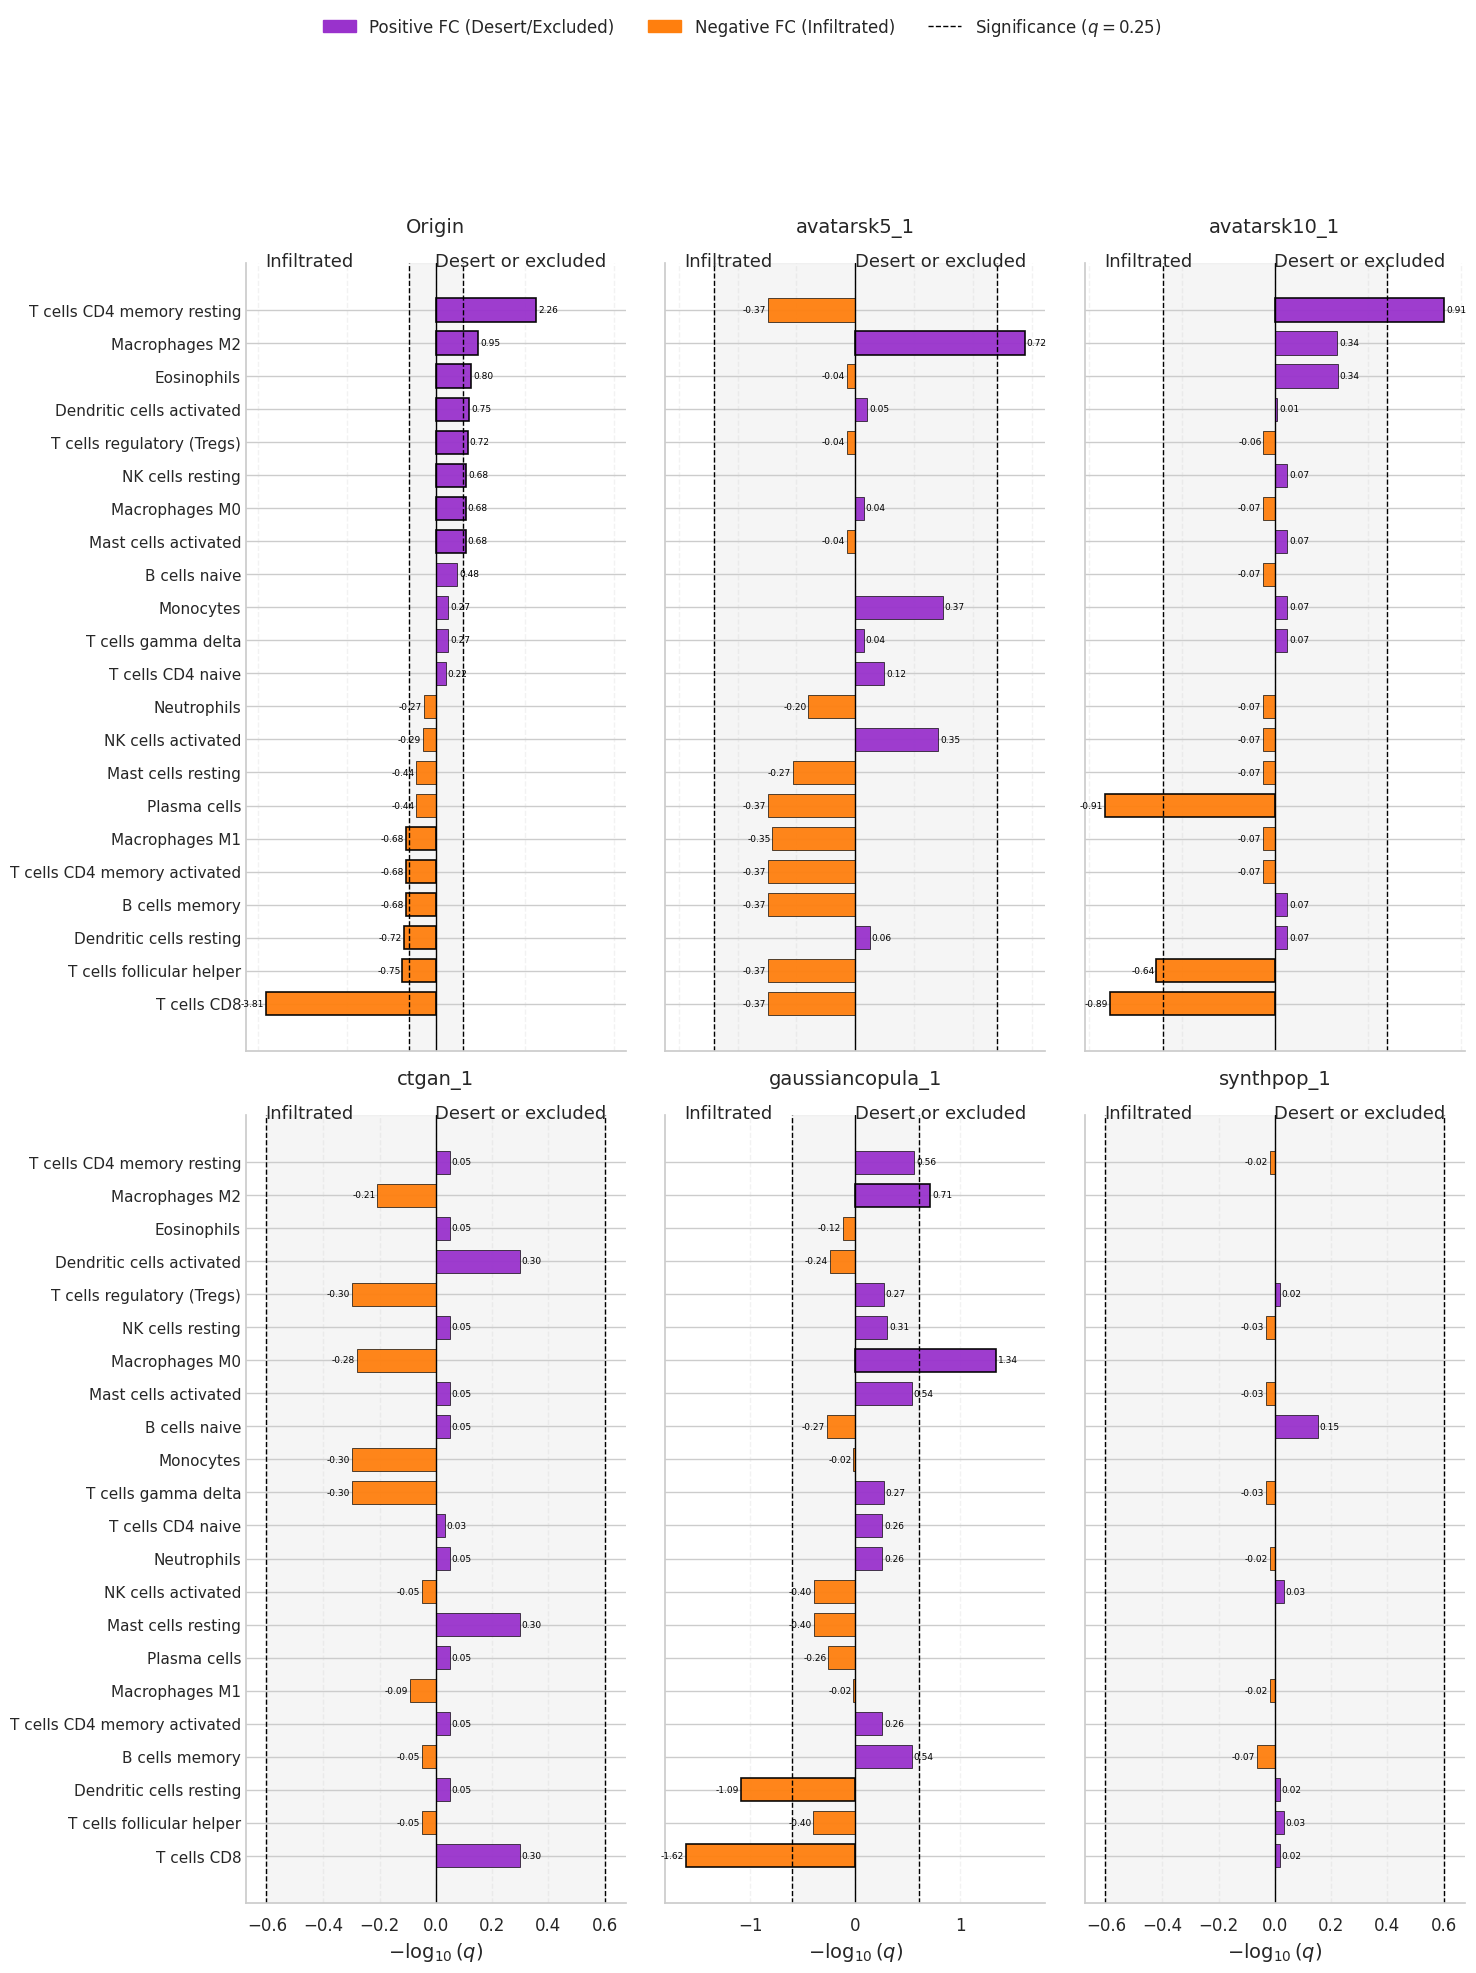

In [22]:
# Sử dụng tham số mới:
fig, axes = plot_deconvolution_grid(
    data_dict=results_deco_dict,
    origin_key="Origin",
    n_cols=3,
    significance_q=0.25,
    
    # Điều chỉnh để khắc phục overlap:
    wspace=0.8,                  # Tăng WSPACE để tạo thêm khoảng trống ngang giữa các subplot
    left_margin_factor=0.22,     # Tăng lề trái để nhãn Cell Type không bị cắt
    value_label_fontsize=6.5,      # Giảm cỡ chữ nhãn giá trị (để fit hơn)
    value_text_pad_factor=0.005  # Tăng khoảng đệm để nhãn giá trị đẩy ra xa khỏi thanh bar
)
fig.savefig(f"ImmuneDecovo/ImmuneDecovolution_Infiltrated_{seed}.png", dpi = 300, bbox_inches="tight")
plt.show()

In [12]:
from collections import Iterable
def _to_set(pathways: Iterable[Any], case_sensitive: bool = False) -> set:
    if pathways is None:
        return set()
    if not case_sensitive:
        return {str(x).strip().lower() for x in pathways if pd.notna(x)}
    else:
        return {str(x).strip() for x in pathways if pd.notna(x)}


def compute_jaccard_indices(
    original_pathways: Iterable[Any],
    synth_pathways_dict: Dict[str, Iterable[Any]],
    case_sensitive: bool = False,
) -> pd.DataFrame:
    """
    The Jaccard index is defined as:
        J(A, B) = |A ∩ B| / |A ∪ B|
    """
    if not isinstance(synth_pathways_dict, dict):
        raise ValueError("synth_pathways_dict must be a dict mapping dataset name -> iterable of pathways")

    A = _to_set(original_pathways, case_sensitive=case_sensitive)
    rows = []
    for ds_name, synth_paths in synth_pathways_dict.items():
        B = _to_set(synth_paths, case_sensitive=case_sensitive)
        inter = A.intersection(B)
        union = A.union(B)
        inter_size = len(inter)
        union_size = len(union)

        if union_size == 0:
            # both sets empty -> identical
            j = 1.0
        else:
            j = inter_size / union_size

        rows.append(
            {
                "Dataset": ds_name,
                "Original_count": len(A),
                "Synthetic_count": len(B),
                "Intersection": inter_size,
                "Union": union_size,
                "Jaccard": j,
            }
        )

    df = pd.DataFrame(rows, columns=["Dataset", "Original_count", "Synthetic_count", "Intersection", "Union", "Jaccard"])
    return df


def extract_significant_cells(
    df: pd.DataFrame,
    cell_col: str = "Gene",
    adj_p_col: str = "padj",
    threshold: float = 0.05,
) -> List[str]:
    if df is None or df.empty:
        return []
    if cell_col not in df.columns or adj_p_col not in df.columns:
        return []
    sub = df[df[adj_p_col].astype(float) < float(threshold)].copy()
    # drop NA/empty terms and return list
    sub = sub[sub[cell_col].notna()]
    return [str(x).strip() for x in sub[cell_col].tolist()]

/tmp/ipykernel_1994662/3308640505.py:1: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated since Python 3.3, and in 3.10 it will stop working
  from collections import Iterable


In [29]:
orig_cells = extract_significant_cells(results_deco_dict["Origin"], cell_col="Cell Type", adj_p_col="q-value", threshold=0.25)
synth_cells_dict = {k: extract_significant_cells(v, cell_col="Cell Type", adj_p_col="q-value", threshold=0.25)
                     for k, v in results_deco_dict.items() if k != "Origin"}
jaccard_df = compute_jaccard_indices(orig_cells, synth_cells_dict)
jaccard_df.to_csv(f"ImmuneDecovo/JaccardIndex_{seed}.csv", index = False)
jaccard_df

,Dataset,Original_count,Synthetic_count,Intersection,Union,Jaccard
0,avatarsk5_42,14,0,0,14,0.000000
1,avatarsk10_42,14,5,4,15,0.266667
2,ctgan_42,14,0,0,14,0.000000
3,gaussiancopula_42,14,7,4,17,0.235294
4,synthpop_42,14,0,0,14,0.000000


In [26]:
CellDecovolution_list = []
for name, df in results_deco_dict.items():
    df['Rank_score2']=df['Log2FC']*df['-log10_q_value']
    CellDecovolution_list.append(df)
    
CellDecovolution_df = pd.concat(CellDecovolution_list, axis = 0)
pivot_df = CellDecovolution_df.pivot_table(
    index="Cell Type",
    columns="Dataset",
    values="Rank_score2"
)
if "tvae_42" not in pivot_df.columns.tolist():
    pivot_df["tvae_42"] = np.nan

origin_values = pivot_df["Origin"]

results = []

for dataset in pivot_df.columns:
    if dataset == "Origin":
        continue  # skip comparison with itself
    
    x = origin_values
    y = pivot_df[dataset]

    # Drop rows where either side is NaN
    valid = ~(x.isna() | y.isna())
    rho, pval = spearmanr(x[valid], y[valid])

    results.append({
        "Dataset": dataset,
        "Spearman_rho": rho,
        "p_value": pval,
        "n_terms_used": valid.sum()
    })

# Convert results to DataFrame
spearman_df = pd.DataFrame(results)
spearman_df.to_csv(f"ImmuneDecovo/Spearman_{seed}.csv", index = False) 
spearman_df

,Dataset,Spearman_rho,p_value,n_terms_used
0,avatarsk10_42,0.503106,0.017000,22
1,avatarsk5_42,0.406445,0.060507,22
2,ctgan_42,0.258046,0.246268,22
3,gaussiancopula_42,0.530209,0.011140,22
4,synthpop_42,-0.138340,0.539242,22
5,tvae_42,NaN,NaN,0


In [27]:
# -*- coding: utf-8 -*-
def plot_jaccard_vs_spearman(
    jaccard_df: pd.DataFrame,
    spearman_df: pd.DataFrame,
    dataset_col: str = "Dataset",
    jaccard_col: str = "Jaccard",
    spearman_col: str = "Spearman_rho",
    size_col: Optional[str] = "Synthetic_count",
    annotate: bool = True,
    figsize: Tuple[float, float] = (8, 6),
    savepath: Optional[str] = None,
    title: Optional[str] = "Jaccard index vs Spearman rho",
) -> Tuple[plt.Figure, plt.Axes]:
    # Validate inputs
    if dataset_col not in jaccard_df.columns:
        raise ValueError(f"{dataset_col} not found in jaccard_df")
    if dataset_col not in spearman_df.columns:
        raise ValueError(f"{dataset_col} not found in spearman_df")
    if jaccard_col not in jaccard_df.columns:
        raise ValueError(f"{jaccard_col} not found in jaccard_df")
    if spearman_col not in spearman_df.columns:
        raise ValueError(f"{spearman_col} not found in spearman_df")

    # Merge on dataset
    df = pd.merge(
        spearman_df,
        jaccard_df,
        on=dataset_col,
        how="outer",
        suffixes=("_spearman", "_jaccard"),
    )

    # Prepare columns
    df = df.rename(columns={jaccard_col: "Jaccard", spearman_col: "Spearman_rho"})
    # If user requested size_col but it has different name in jaccard_df, try to keep as-is
    if size_col is not None and size_col not in df.columns:
        # fall back to n_terms_used or Synthetic_count if available
        if "n_terms_used" in df.columns:
            size_col = "n_terms_used"
        elif "Synthetic_count" in df.columns:
            size_col = "Synthetic_count"
        else:
            size_col = None

    # Drop rows that do not have both metrics (can't plot)
    plot_df = df.loc[df["Jaccard"].notna() & df["Spearman_rho"].notna()].copy()

    # If no rows to plot, create empty figure with message
    if plot_df.shape[0] == 0:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, "No datasets with both Jaccard and Spearman available", ha="center", va="center")
        ax.axis("off")
        if savepath:
            fig.savefig(savepath, dpi=300, bbox_inches="tight")
        return fig, ax

    # # Compute Spearman correlation between Jaccard and Spearman_rho (on available rows)
    # rho, pval = spearmanr(plot_df["Jaccard"], plot_df["Spearman_rho"], nan_policy="omit")

    # Determine point sizes
    if size_col is not None:
        # scale sizes to a reasonable range
        raw_sizes = plot_df[size_col].fillna(0).astype(float)
        # map zero -> small, others scaled
        min_size = 50
        max_size = 450
        if raw_sizes.max() == raw_sizes.min():
            sizes = np.full(len(raw_sizes), (min_size + max_size) / 2.0)
        else:
            sizes = min_size + (raw_sizes - raw_sizes.min()) / (raw_sizes.max() - raw_sizes.min()) * (max_size - min_size)
    else:
        sizes = 120

    # Create plot
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    scatter = ax.scatter(
        x=plot_df["Jaccard"],
        y=plot_df["Spearman_rho"],
        s=sizes,
        c="tab:blue",
        edgecolor="k",
        alpha=0.85,
        linewidth=0.6,
        zorder=3,
    )


    # Annotate each point with dataset name if requested (with small offset)
    if annotate:
        for _, row in plot_df.iterrows():
            dx = 0.005 * (ax.get_xlim()[1] - ax.get_xlim()[0])  # small fraction of x-range
            dy = 0.02 * (ax.get_ylim()[1] - ax.get_ylim()[0])  # small fraction of y-range
            ax.text(
                row["Jaccard"] + dx,
                row["Spearman_rho"] + dy,
                str(row[dataset_col]),
                fontsize=8,
                verticalalignment="bottom",
                horizontalalignment="left",
            )

    # Labels, title, legend, annotation for correlation
    ax.set_xlabel("Jaccard index", fontsize=11)
    ax.set_ylabel("Spearman rho", fontsize=11)
    ax.set_title(title, fontsize=12)



    # A grid and tight layout
    ax.grid(alpha=0.4, linestyle="--")
    plt.tight_layout()

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, ax

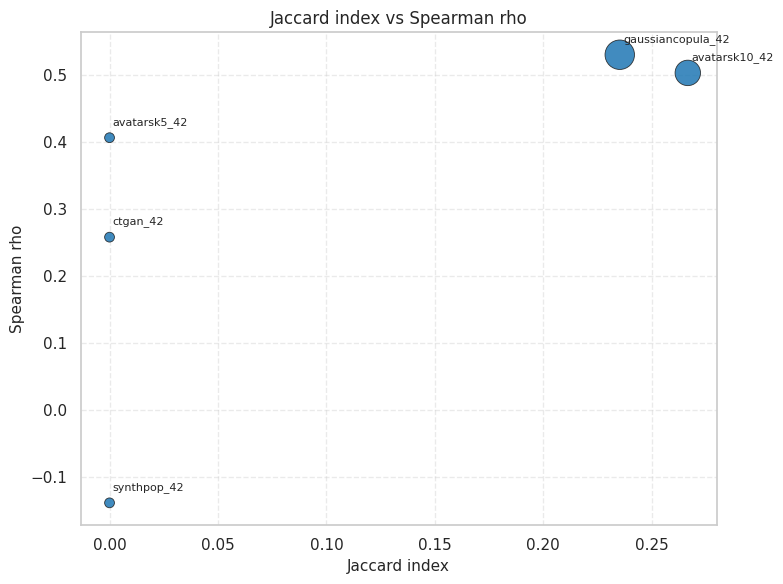

In [28]:
fig, ax = plot_jaccard_vs_spearman(jaccard_df, spearman_df, 
                                   size_col="Synthetic_count", annotate=True, savepath=None)
plt.show()